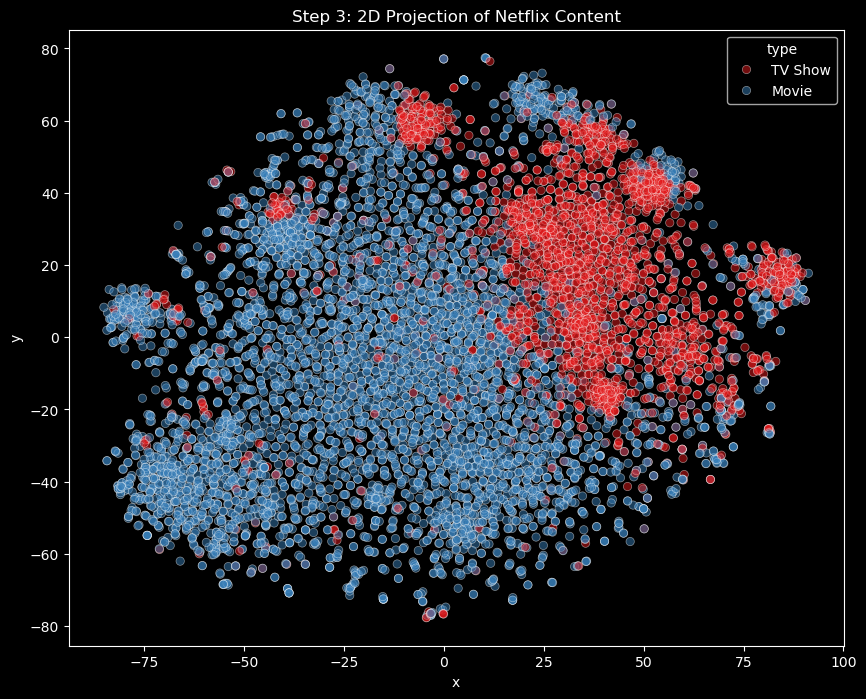

Step 3 successfully completed!


In [2]:
import pandas as pd
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\Soumya_SRB\Desktop\Netflix-Content-Clustering-Engine\NetflixSimple.csv')
# 2. PREPROCESSING 
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['listed_in'] = df['listed_in'].fillna('Unknown')
df['description'] = df['description'].fillna('Unknown')

def clean_text(text):
    text = str(text).lower()
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
    return text
df['text_features'] = df['director'] + ' ' + df['cast'] + ' ' + df['listed_in'] + ' ' + df['description']
df['text_features'] = df['text_features'].apply(clean_text)


# 3. VECTORIZATION & DIMENSIONALITY REDUCTION 
tfidf = TfidfVectorizer(stop_words='english', max_features=5000) # Limit features to save memory
tfidf_matrix = tfidf.fit_transform(df['text_features'])


# PCA to reduce complexity
pca = PCA(n_components=0.95, random_state=42)
tfidf_matrix_pca = pca.fit_transform(tfidf_matrix.toarray())

# t-SNE to create 2D coordinates 
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(tfidf_matrix_pca)
df['x'] = tsne_results[:, 0]
df['y'] = tsne_results[:, 1]


# 4. VISUALIZE 
plt.style.use('dark_background')
plt.figure(figsize=(10, 8))
sns.scatterplot(x='x', y='y', data=df, alpha=0.5, hue='type', palette='Set1')
plt.title('Step 3: 2D Projection of Netflix Content')
plt.show()

print("Step 3 successfully completed!")